In [1]:
"""
Pay Parity Across Multiple Demographics - MLPR Project
Authors: Kavyaa Agrawal, Sadhika Anand, Sahil Gada

REGRESSION VERSION — predicts actual WAGE income (WAGP in $).

Dataset: 5-state ACS master (CA, TX, FL, NY, IL)  — 1,238,284 raw rows, 12 columns:
  AGEP   Age
  COW    Class of worker
  MAR    Marital status
  SCHL   Education level
  SEX    Sex (1=Male, 2=Female)
  WAGP   Wage/salary income  <-- PRIMARY regression target
  WKHP   Hours worked per week
  INDP   Industry code
  OCCP   Occupation code
  PINCP  Total personal income (kept as a secondary reference column)
  RAC1P  Race
  STATE  State abbreviation (CA / TX / FL / NY / IL)

Why WAGP and not PINCP?
  WAGP = wages/salary only — directly measures labour market pay discrimination.
  PINCP = total income including investments, benefits, etc. — noisier for pay parity.

This script handles:
1. Loading the dataset
2. Cleaning (missing values, duplicates, age filter, WAGP > 0 filter)
3. Decoding numeric codes to human-readable labels
4. Outlier removal (IQR capping)
5. Low-earnings occupation filter
6. Feature engineering (log-transform target, normalise, target-encode, encode STATE)
7. 19 visualisations suited to a continuous wage target
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings("ignore")

from google.colab import files
uploaded = files.upload()

# ─────────────────────────────────────────────
# PLOT STYLE
# ─────────────────────────────────────────────
FEMALE_COLOR = "#5b7fa6"
MALE_COLOR   = "#c87941"
BG_COLOR     = "#f8f8f8"
plt.rcParams.update({
    "figure.facecolor": BG_COLOR,
    "axes.facecolor":   BG_COLOR,
    "axes.edgecolor":   "#cccccc",
    "axes.labelsize":   11,
    "axes.titlesize":   13,
    "axes.titleweight": "bold",
    "xtick.labelsize":  9,
    "ytick.labelsize":  9,
    "font.family":      "sans-serif",
})
dollar_fmt = mticker.FuncFormatter(lambda x, _: f"${x:,.0f}")


# ══════════════════════════════════════════════════════════════════
# SECTION 1 — LOAD DATA
# ══════════════════════════════════════════════════════════════════
print("=" * 60)
print("SECTION 1: Loading data")
print("=" * 60)

df = pd.read_csv("pay_parity_5_states_master.csv")
print(f"Raw shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Columns: {list(df.columns)}")
print(f"\nState breakdown:\n{df['STATE'].value_counts().to_string()}")
print(f"\nMissing values per column:\n{df.isnull().sum().to_string()}")

# Track row counts at each step for a final summary
counts = {"0_raw": len(df)}



Saving pay_parity_5_states_master.csv to pay_parity_5_states_master.csv
SECTION 1: Loading data
Raw shape: 1,238,284 rows × 13 columns
Columns: ['PWGTP', 'AGEP', 'COW', 'MAR', 'SCHL', 'SEX', 'WAGP', 'WKHP', 'INDP', 'OCCP', 'PINCP', 'RAC1P', 'STATE']

State breakdown:
STATE
CA    393725
TX    292272
FL    213167
NY    210150
IL    128970

Missing values per column:
PWGTP         0
AGEP          0
COW      502225
MAR           0
SCHL      31174
SEX           0
WAGP     180156
WKHP     602276
INDP     502225
OCCP     502225
PINCP    180156
RAC1P         0
STATE         0


In [2]:

# ══════════════════════════════════════════════════════════════════
# SECTION 2 — INITIAL FILTERS (before decoding)
#
# 2a. Keep only working-age adults (18+).
#     Children and teenagers are not part of the labour market
#     and would only add noise to a wage model.
#
# 2b. Keep only rows where WAGP > 0.
#     WAGP = 0 means no wage income (retired, unemployed, students).
#     These records are not relevant to a pay-parity study.
#     We do NOT filter on PINCP here because PINCP includes investment
#     income and transfers — someone can have PINCP > 0 but WAGP = 0.
# ══════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("SECTION 2: Initial filters (age >= 18, WAGP > 0)")
print("=" * 60)

before = len(df)
df = df[df["AGEP"] >= 18].copy()
print(f"Removed {before - len(df):,} rows where age < 18")
counts["1_after_age_filter"] = len(df)

before = len(df)
df = df[df["WAGP"] > 0].copy()
print(f"Removed {before - len(df):,} rows where WAGP <= 0 (no wage income)")
counts["2_after_wagp_filter"] = len(df)

print(f"Remaining: {len(df):,} rows")


# ══════════════════════════════════════════════════════════════════
# SECTION 3 — DECODE NUMERIC CODES TO HUMAN-READABLE LABELS
# ══════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("SECTION 3: Decoding ACS numeric codes -> labels")
print("=" * 60)

# -- SEX ----------------------------------------------------------
sex_map = {1: "Male", 2: "Female"}
df["SEX_LABEL"] = df["SEX"].map(sex_map)

# -- MARITAL STATUS (MAR) -----------------------------------------
mar_map = {1: "Married", 2: "Widowed", 3: "Divorced",
           4: "Separated", 5: "Never Married"}
df["MAR_LABEL"] = df["MAR"].map(mar_map)

# -- RACE (RAC1P) -------------------------------------------------
rac_map = {
    1: "White", 2: "Black", 3: "American Indian",
    4: "Alaska Native", 5: "American Indian/Alaska Native",
    6: "Asian", 7: "Native Hawaiian", 8: "Other",
    9: "Two or more races",
}
df["RAC1P_LABEL"] = df["RAC1P"].map(rac_map)

# -- CLASS OF WORKER (COW) ----------------------------------------
cow_map = {
    1: "Private for-profit", 2: "Private non-profit",
    3: "Local government",   4: "State government",
    5: "Federal government", 6: "Self-employed (inc)",
    7: "Self-employed (not inc)", 8: "Unpaid family",
    9: "Unemployed",
}
df["COW_LABEL"] = df["COW"].map(cow_map)

# -- EDUCATION (SCHL) ---------------------------------------------
schl_map = {
    1: "No schooling", 2: "Nursery", 3: "Kindergarten",
    4: "Grade 1",  5: "Grade 2",  6: "Grade 3",  7: "Grade 4",
    8: "Grade 5",  9: "Grade 6", 10: "Grade 7", 11: "Grade 8",
    12: "Grade 9", 13: "Grade 10", 14: "Grade 11", 15: "Grade 12",
    16: "High School", 17: "GED",
    18: "Some College <1yr", 19: "Some College >1yr",
    20: "Associate", 21: "Bachelor", 22: "Master",
    23: "Professional", 24: "Doctorate",
}
df["SCHL_LABEL"] = df["SCHL"].map(schl_map)

print("Label columns added: SEX_LABEL, MAR_LABEL, RAC1P_LABEL, COW_LABEL, SCHL_LABEL")


# ══════════════════════════════════════════════════════════════════
# SECTION 4 — CLEANING: missing values & duplicates
#
# After filtering to WAGP > 0 and age >= 18, we drop any remaining
# rows that are missing values in the key feature columns.
# COW, OCCP, WKHP, SCHL can still have NaNs (e.g. self-employed
# people sometimes skip occupation fields).
# ══════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("SECTION 4: Cleaning — missing values & duplicates")
print("=" * 60)

before = len(df)
key_cols = ["SEX", "SCHL", "MAR", "RAC1P", "COW", "OCCP", "AGEP", "WKHP", "WAGP"]
df.dropna(subset=key_cols, inplace=True)
df.drop_duplicates(inplace=True)
after = len(df)
print(f"Removed {before - after:,} rows (missing values / duplicates)")
print(f"Clean dataset: {after:,} rows")
counts["3_after_cleaning"] = len(df)


# ══════════════════════════════════════════════════════════════════
# SECTION 5 — OUTLIER REMOVAL (IQR capping)
#
# Wages have an extreme right tail (a few people earn millions).
# IQR capping clips these to the 1.5×IQR upper fence rather than
# deleting the row — keeps data volume while reducing distortion.
# ══════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("SECTION 5: Outlier removal (IQR capping on continuous cols)")
print("=" * 60)

def iqr_cap(series, name=""):
    """Clip values outside 1.5 × IQR to the fence values."""
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    capped = series.clip(lower, upper)
    changed = (series != capped).sum()
    print(f"  {name}: capped {changed:,} values  [{lower:.1f} - {upper:.1f}]")
    return capped

df["AGEP"] = iqr_cap(df["AGEP"], "AGEP  (age)")
df["WKHP"] = iqr_cap(df["WKHP"], "WKHP  (hrs/week)")
# Cap the wage — reduces extreme-earner influence without losing rows
df["WAGP"] = iqr_cap(df["WAGP"], "WAGP  (wage $)")
counts["4_after_iqr_cap"] = len(df)   # same count, no rows removed

print(f"\nWAGP after capping:\n{df['WAGP'].describe().apply(lambda x: f'${x:,.0f}')}")


# ══════════════════════════════════════════════════════════════════
# SECTION 6 — REMOVE LOW-EARNINGS OCCUPATIONS
#
# Occupations whose median wage < $15,000 (roughly half-time at
# federal minimum wage) offer almost no variance for pay-parity
# analysis. Dropping them sharpens the model signal.
# ══════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("SECTION 6: Removing very-low-earnings occupations (median WAGP < $15k)")
print("=" * 60)

occ_median = df.groupby("OCCP")["WAGP"].median()
valid_occp  = occ_median[occ_median >= 15_000].index
before_occ  = len(df)
df = df[df["OCCP"].isin(valid_occp)].copy()
print(f"Removed {before_occ - len(df):,} rows from very-low-earnings occupations")
print(f"Dataset after occupation filter: {len(df):,} rows")
counts["5_after_occ_filter"] = len(df)



SECTION 2: Initial filters (age >= 18, WAGP > 0)
Removed 224,388 rows where age < 18
Removed 424,383 rows where WAGP <= 0 (no wage income)
Remaining: 589,513 rows

SECTION 3: Decoding ACS numeric codes -> labels
Label columns added: SEX_LABEL, MAR_LABEL, RAC1P_LABEL, COW_LABEL, SCHL_LABEL

SECTION 4: Cleaning — missing values & duplicates
Removed 338 rows (missing values / duplicates)
Clean dataset: 589,175 rows

SECTION 5: Outlier removal (IQR capping on continuous cols)
  AGEP  (age): capped 142 values  [-6.5 - 93.5]
  WKHP  (hrs/week): capped 184,611 values  [27.5 - 47.5]
  WAGP  (wage $): capped 37,377 values  [-75000.0 - 189000.0]

WAGP after capping:
count    $589,175
mean      $63,287
std       $52,092
min            $4
25%       $24,000
50%       $50,000
75%       $90,000
max      $189,000
Name: WAGP, dtype: object

SECTION 6: Removing very-low-earnings occupations (median WAGP < $15k)
Removed 13,326 rows from very-low-earnings occupations
Dataset after occupation filter: 575,

In [3]:
# ══════════════════════════════════════════════════════════════════
# SECTION 7 — FEATURE ENGINEERING
#
# 7a. Log-transform WAGP -> WAGP_LOG  (regression target)
#     Wages are right-skewed; log makes the distribution near-normal
#     which is much better for XGBoost regression.
#     To recover dollar predictions: np.expm1(model.predict(X))
#
# 7b. MinMax-normalise AGEP and WKHP (0-1).
#
# 7c. Smoothed mean-target encoding for high-cardinality categoricals.
#     Each category level is replaced by its smoothed mean log-wage,
#     shrunk toward the global mean for rare levels.
#
# 7d. One-hot encode STATE (5 states -> 5 binary columns).
#     State captures regional cost-of-living differences which are
#     a real confound in cross-state wage comparisons.
#
# 7e. Binary-encode SEX (Male=1, Female=0).
# ══════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("SECTION 7: Feature engineering")
print("=" * 60)

# -- 7a. Log-transform the wage target ----------------------------
df["WAGP_LOG"] = np.log1p(df["WAGP"])
print("Created WAGP_LOG = log1p(WAGP)  <-- regression target")
print(f"  WAGP_LOG range: {df['WAGP_LOG'].min():.2f} - {df['WAGP_LOG'].max():.2f}")

# -- 7b. MinMax normalisation on continuous features --------------
scaler   = MinMaxScaler()
num_cols = ["AGEP", "WKHP"]
df[num_cols] = scaler.fit_transform(df[num_cols])
print(f"Normalised (MinMax -> 0-1): {num_cols}")

# -- 7c. Smoothed mean-target encoding ----------------------------
def target_encode(df, col, target="WAGP_LOG", smoothing=10):
    """
    Smoothed mean-target encoding:
        encoded = (n_i * mean_i + k * global_mean) / (n_i + k)
    k = smoothing factor; higher = more regularisation for rare levels.
    """
    global_mean = df[target].mean()
    stats  = df.groupby(col)[target].agg(["mean", "count"])
    smooth = (stats["count"] * stats["mean"] + smoothing * global_mean) / \
             (stats["count"] + smoothing)
    return df[col].map(smooth)

# -- 7d. One-hot encode STATE ------------------------------------
# This gives the model a way to capture state-level wage differences
# (e.g. CA and NY generally pay more than FL for the same job).
state_dummies = pd.get_dummies(df["STATE"], prefix="STATE", drop_first=False)
df = pd.concat([df, state_dummies], axis=1)
state_cols = list(state_dummies.columns)
print(f"One-hot encoded STATE -> {state_cols}")

# -- 7e. Binary-encode SEX ----------------------------------------
df["SEX_BIN"] = (df["SEX"] == 1).astype(int)   # 1 = Male, 0 = Female
print("Binary-encoded: SEX -> SEX_BIN (1 = Male, 0 = Female)")

# -- 7f. Assemble the model-ready dataframe -----------------------
model_cols = (
    ["AGEP", "COW", "SCHL", "MAR",
     "OCCP", "WKHP", "SEX_BIN", "RAC1P"]
    + state_cols
    + ["WAGP_LOG"]   # <-- regression target, always last
)
df_model = df[model_cols].copy()
print(f"\nModel-ready dataframe shape: {df_model.shape}")
print(df_model.head())

# Save
df.to_csv("pay_parity_preprocessed.csv", index=False)
df_model.to_csv("pay_parity_model_ready.csv", index=False)
print("\nSaved: pay_parity_preprocessed.csv  (full, with labels)")
print("Saved: pay_parity_model_ready.csv   (numeric, model-ready)")
print("       -> Target = WAGP_LOG  |  use np.expm1(pred) to get $ back")


# ══════════════════════════════════════════════════════════════════
# SECTION 8 — ROW-COUNT SUMMARY
# Print a clear table of how many rows were removed at each step.
# ══════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("SECTION 8: Data point count summary")
print("=" * 60)

counts["6_final"] = len(df)
labels = {
    "0_raw":               "Raw dataset",
    "1_after_age_filter":  "After removing age < 18",
    "2_after_wagp_filter": "After removing WAGP <= 0",
    "3_after_cleaning":    "After missing values / duplicates",
    "4_after_iqr_cap":     "After IQR capping (no rows removed)",
    "5_after_occ_filter":  "After low-earnings occupation filter",
    "6_final":             "FINAL dataset",
}
prev = None
for key, label in labels.items():
    n = counts[key]
    if prev is not None:
        removed = prev - n
        pct     = removed / counts["0_raw"] * 100
        print(f"  {label:<45} {n:>9,}  (removed {removed:>7,} = {pct:.1f}% of raw)")
    else:
        print(f"  {label:<45} {n:>9,}")
    prev = n

total_removed = counts["0_raw"] - counts["6_final"]
print(f"\n  Total rows removed: {total_removed:,}  "
      f"({total_removed/counts['0_raw']*100:.1f}% of raw)")
print(f"  Final dataset:      {counts['6_final']:,} rows")




SECTION 7: Feature engineering
Created WAGP_LOG = log1p(WAGP)  <-- regression target
  WAGP_LOG range: 1.61 - 12.15
Normalised (MinMax -> 0-1): ['AGEP', 'WKHP']
One-hot encoded STATE -> ['STATE_CA', 'STATE_FL', 'STATE_IL', 'STATE_NY', 'STATE_TX']
Binary-encoded: SEX -> SEX_BIN (1 = Male, 0 = Female)

Model-ready dataframe shape: (575849, 14)
        AGEP  COW  SCHL  MAR    OCCP   WKHP  SEX_BIN  RAC1P  STATE_CA  \
0   0.357616  2.0   7.0    1  9150.0  1.000        1      9      True   
2   0.039735  5.0  20.0    5   725.0  0.000        0      8      True   
4   0.013245  1.0  18.0    5  1970.0  0.000        0      6      True   
13  0.556291  2.0  24.0    1   725.0  0.875        0      1      True   
18  0.013245  4.0  19.0    5  4130.0  0.000        1      1      True   

    STATE_FL  STATE_IL  STATE_NY  STATE_TX   WAGP_LOG  
0      False     False     False     False  11.156265  
2      False     False     False     False   8.006701  
4      False     False     False     False   9.4

In [4]:
# =========================
# NEURAL NETWORK FOR WAGE PREDICTION
# =========================

# Install TensorFlow if needed
!pip install -q tensorflow

import pandas as pd
import numpy as np
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# =========================
# 1. DEFINE FEATURES + TARGET
# =========================

# CHANGE 'wage' IF YOUR TARGET COLUMN HAS A DIFFERENT NAME
target_column = 'WAGP_LOG'

# One-hot encode categorical columns automatically
df_encoded = pd.get_dummies(df, drop_first=True)

# Features and target
X = df_encoded.drop(target_column, axis=1)
y = df_encoded[target_column]

# =========================
# 2. TRAIN TEST SPLIT
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# =========================
# 3. FEATURE SCALING
# =========================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)




In [16]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 575849 entries, 0 to 1238283
Data columns (total 66 columns):
 #   Column                                     Non-Null Count   Dtype  
---  ------                                     --------------   -----  
 0   PWGTP                                      575849 non-null  int64  
 1   AGEP                                       575849 non-null  float64
 2   COW                                        575849 non-null  float64
 3   MAR                                        575849 non-null  int64  
 4   SCHL                                       575849 non-null  float64
 5   SEX                                        575849 non-null  int64  
 6   WAGP                                       575849 non-null  float64
 7   WKHP                                       575849 non-null  float64
 8   INDP                                       575849 non-null  float64
 9   OCCP                                       575849 non-null  float64
 10  PINCP       

In [6]:
print(df[target_column].describe())

count    575849.000000
mean         10.616615
std           1.172175
min           1.609438
25%          10.126671
50%          10.819798
75%          11.407576
max          12.149508
Name: WAGP_LOG, dtype: float64


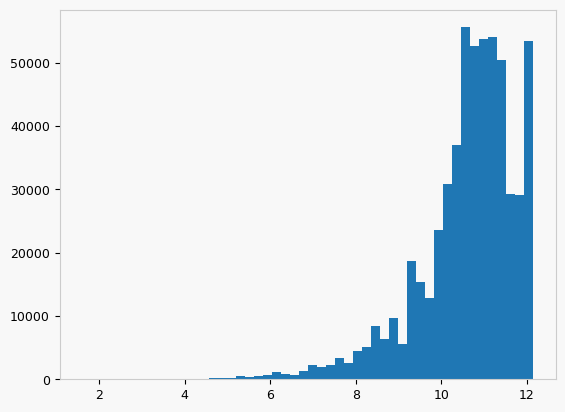

In [7]:
plt.hist(df[target_column], bins=50)
plt.show()

In [8]:
plt.figure(figsize=(8,6))

residuals = y_test - predictions

plt.scatter(y_test, residuals, alpha=0.5)

plt.axhline(0)

plt.xlabel("Actual Wage")
plt.ylabel("Residuals")

plt.title("Residuals vs Actual Wage")

plt.show()

NameError: name 'predictions' is not defined

<Figure size 800x600 with 0 Axes>

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 575849 entries, 0 to 1238283
Data columns (total 25 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   PWGTP        575849 non-null  int64  
 1   AGEP         575849 non-null  float64
 2   COW          575849 non-null  float64
 3   MAR          575849 non-null  int64  
 4   SCHL         575849 non-null  float64
 5   SEX          575849 non-null  int64  
 6   WAGP         575849 non-null  float64
 7   WKHP         575849 non-null  float64
 8   INDP         575849 non-null  float64
 9   OCCP         575849 non-null  float64
 10  PINCP        575849 non-null  float64
 11  RAC1P        575849 non-null  int64  
 12  STATE        575849 non-null  object 
 13  SEX_LABEL    575849 non-null  object 
 14  MAR_LABEL    575849 non-null  object 
 15  RAC1P_LABEL  575849 non-null  object 
 16  COW_LABEL    575849 non-null  object 
 17  SCHL_LABEL   575849 non-null  object 
 18  WAGP_LOG     575849 non-null


FILTERED DATASET SHAPE: (575849, 12)

FINAL FEATURES USED IN NEURAL NETWORK (After Encoding):
13 Total Features

Training Model...
Epoch 1/50
2880/2880 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - loss: 1.1264 - mae: 1.4639 - val_loss: 0.3147 - val_mae: 0.5901
Epoch 2/50
2880/2880 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - loss: 0.3868 - mae: 0.7047 - val_loss: 0.2872 - val_mae: 0.5882
Epoch 3/50
2880/2880 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - loss: 0.3459 - mae: 0.6739 - val_loss: 0.2742 - val_mae: 0.5795
Epoch 4/50
2880/2880 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - loss: 0.3330 - mae: 0.6611 - val_loss: 0.2702 - val_mae: 0.5735
Epoch 5/50
2880/2880 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - loss: 0.3269 - mae: 0.6538 - val_loss: 0.2699 - val_mae: 0.5741
Epoch 6/50
2880/2880 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - loss: 0.3210 - mae: 0.6454 - val_loss: 0.2694 - val_mae: 0.5737
Epoch 7/50
2880/2880 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - loss: 0.3176 - mae: 0.6408 - val_loss: 0.2672 - val_mae: 0.5677
Epoch 8/50
2880/2880 

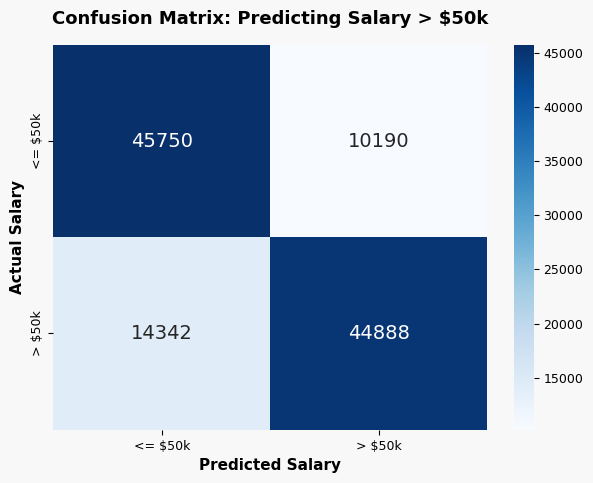


Classification Report for $50k Threshold:
              precision    recall  f1-score   support

     <= $50k       0.76      0.82      0.79     55940
      > $50k       0.81      0.76      0.79     59230

    accuracy                           0.79    115170
   macro avg       0.79      0.79      0.79    115170
weighted avg       0.79      0.79      0.79    115170


TOLERANCE VS ACCURACY GRAPH


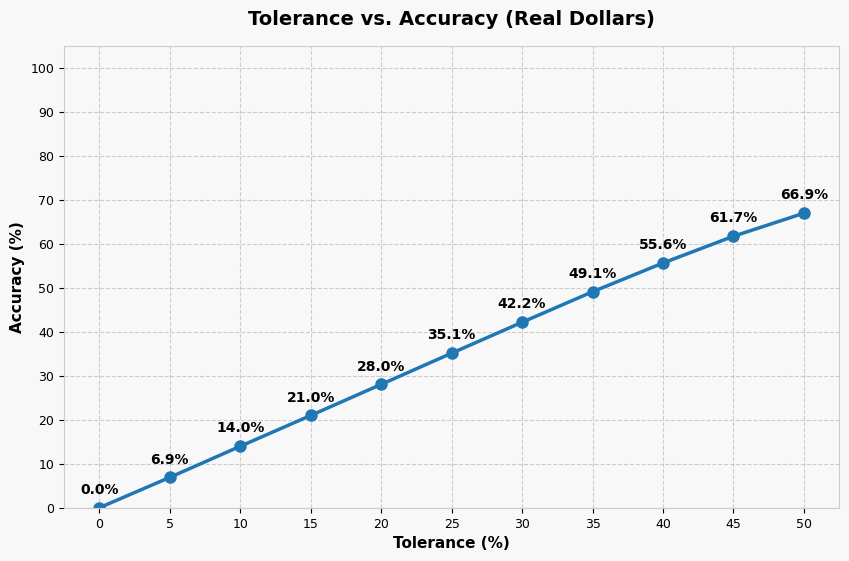


CREATING DEEP SHAP EXPLAINER
Calculating SHAP values...

TOP 10 FEATURES AFFECTING WAGES:
     Feature  Mean_SHAP_Impact
1       WKHP          0.425904
4       SCHL          0.163164
2       OCCP          0.142064
3       AGEP          0.139999
12  STATE_TX          0.095147
0        SEX          0.080396
5        MAR          0.063760
6       INDP          0.041042
9   STATE_FL          0.040896
8        COW          0.032929


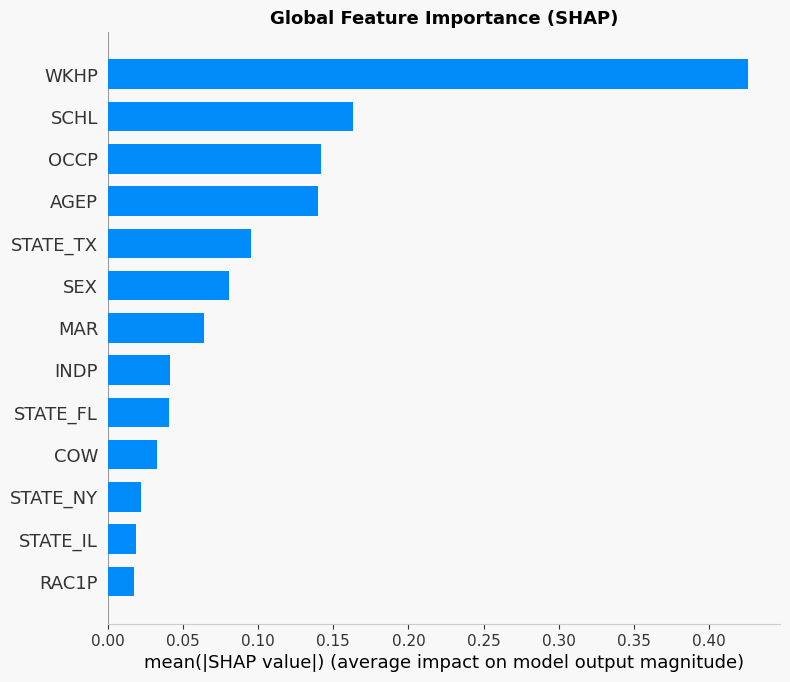

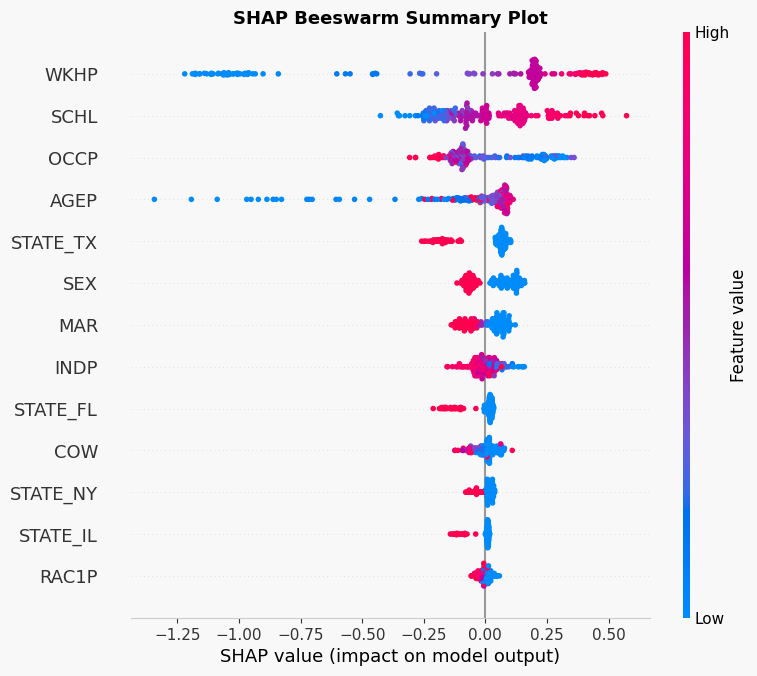

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


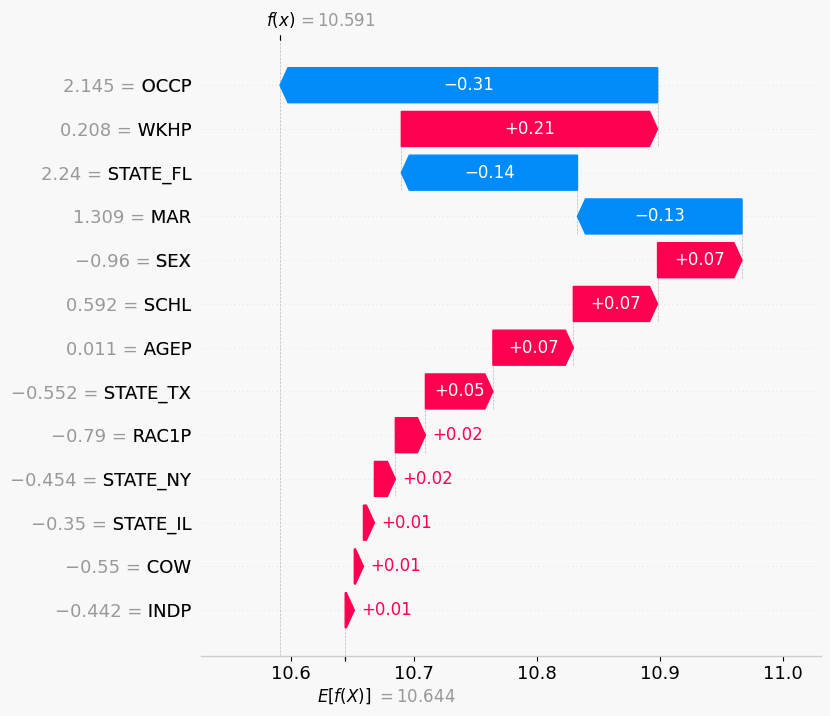


GENDER PAY PARITY ANALYSIS

Male SHAP Average   (SEX=1) : nan
Female SHAP Average (SEX=0) : nan


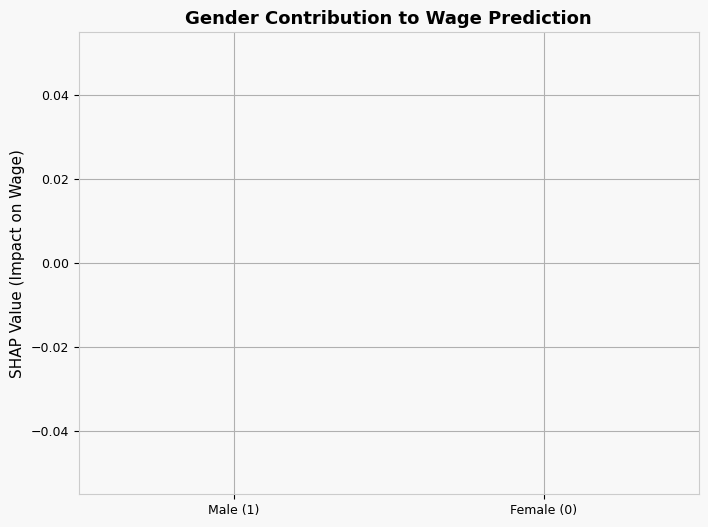

<Figure size 800x600 with 0 Axes>

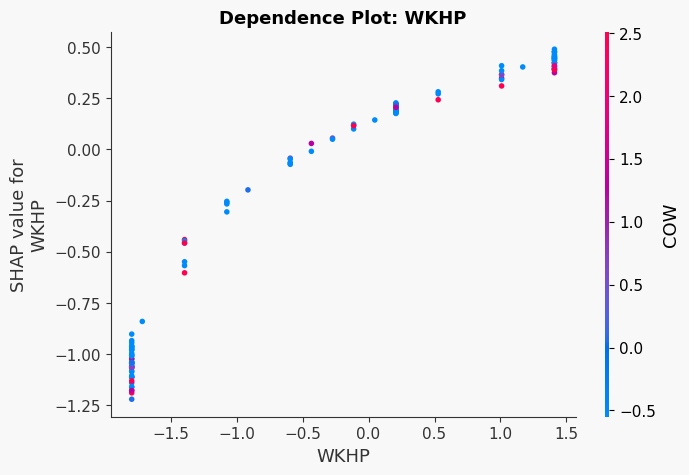

<Figure size 800x600 with 0 Axes>

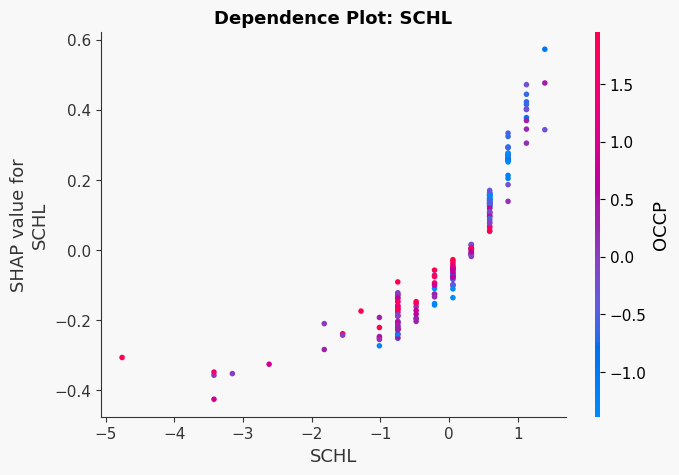

<Figure size 800x600 with 0 Axes>

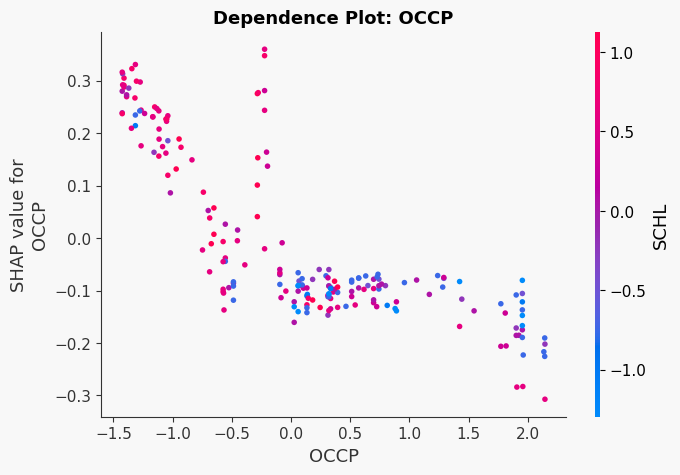


ANALYSIS COMPLETE


In [17]:
# =========================================================
# FINAL CLEAN PAY PARITY MODEL + DEEP SHAP + CUSTOM EVALUATION
# STRICT FEATURE SELECTION (NO LEAKAGE)
# =========================================================

# =========================================================
# INSTALLS
# =========================================================
!pip install -q tensorflow shap seaborn

# =========================================================
# IMPORTS
# =========================================================
import pandas as pd
import numpy as np
import tensorflow as tf
import shap
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    confusion_matrix,
    classification_report
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2

# =========================================================
# REPRODUCIBILITY
# =========================================================
np.random.seed(42)
tf.random.set_seed(42)

# =========================================================
# 1. STRICT FEATURE SELECTION
# =========================================================
# We explicitly restrict the dataframe to ONLY the variables you
# requested, plus the targets needed for training/evaluation.
# Replace with the exact column names as they appear in your 'df'

allowed_columns = [
    "SEX",       # Gender
    "WKHP",      # Working Hours
    "OCCP",      # Occupation
    "AGEP",      # Age
    "SCHL",      # School / Education
    "MAR",       # Marriage
    "INDP",      # Industry
    "RAC1P",     # Race
    "STATE",     # States
    "COW",       # Class of Worker
    "WAGP_LOG",  # Log-Wage (Target for Training)
    "WAGP"       # Raw Wage (Used ONLY for evaluation, dropped from X)
]

# Ensure we only use columns that actually exist in your df
existing_cols = [c for c in allowed_columns if c in df.columns]
df_subset = df[existing_cols].copy()

print("\n===================================================")
print("FILTERED DATASET SHAPE:", df_subset.shape)
print("===================================================")

# =========================================================
# 2. ONE HOT ENCODING
# =========================================================
df_encoded = pd.get_dummies(df_subset, drop_first=True)

# =========================================================
# 3. PREPARE X AND Y (PREVENT WAGE LEAKAGE)
# =========================================================
target_column = "WAGP_LOG"
leakage_cols = ["WAGP", "WAGP_LOG", "PINCP"]

X = df_encoded.drop(columns=leakage_cols, errors="ignore")
y = df_encoded[target_column]
feature_names = X.columns.tolist()

print("\nFINAL FEATURES USED IN NEURAL NETWORK (After Encoding):")
print(len(feature_names), "Total Features")

# =========================================================
# 4. TRAIN TEST SPLIT & SCALING
# =========================================================
# We need to keep track of the original WAGP for our custom graphs
X_train_df, X_test_df, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_df)
X_test = scaler.transform(X_test_df)

# =========================================================
# 5. BUILD & TRAIN NEURAL NETWORK
# =========================================================
model = Sequential([
    Dense(128, activation='relu', kernel_regularizer=l2(0.0005), input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.1),
    Dense(64, activation='relu', kernel_regularizer=l2(0.0005)),
    BatchNormalization(),
    Dropout(0.1),
    Dense(1)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.Huber(),
    metrics=['mae']
)

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("\nTraining Model...")
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)

# =========================================================
# 6. STANDARD PREDICTIONS & METRICS
# =========================================================
predictions = model.predict(X_test).flatten()

mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print("\n===================================================")
print("STANDARD MODEL PERFORMANCE (LOG SCALE)")
print("===================================================")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

# =========================================================
# 7. UN-LOG PREDICTIONS TO REAL DOLLARS
# =========================================================
y_test_dollars = np.expm1(y_test)
predictions_dollars = np.expm1(predictions)

# =========================================================
# 8. NEW GRAPH: CONFUSION MATRIX (> $50,000)
# =========================================================
print("\n===================================================")
print("CONFUSION MATRIX: > $50,000 WAGE")
print("===================================================")

threshold = 50000
y_test_binary = (y_test_dollars > threshold).astype(int)
predictions_binary = (predictions_dollars > threshold).astype(int)

cm = confusion_matrix(y_test_binary, predictions_binary)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['<= $50k', '> $50k'],
            yticklabels=['<= $50k', '> $50k'],
            annot_kws={"size": 14})
plt.title("Confusion Matrix: Predicting Salary > $50k", pad=15, fontweight='bold')
plt.ylabel('Actual Salary', fontweight='bold')
plt.xlabel('Predicted Salary', fontweight='bold')
plt.show()

print("\nClassification Report for $50k Threshold:")
print(classification_report(y_test_binary, predictions_binary, target_names=['<= $50k', '> $50k']))

# =========================================================
# 9. NEW GRAPH: TOLERANCE VS ACCURACY
# =========================================================
print("\n===================================================")
print("TOLERANCE VS ACCURACY GRAPH")
print("===================================================")

tolerances = np.arange(0, 55, 5)
accuracies = []
abs_pct_error = np.abs((predictions_dollars - y_test_dollars) / y_test_dollars) * 100

for t in tolerances:
    acc = np.mean(abs_pct_error <= t) * 100
    accuracies.append(acc)

plt.figure(figsize=(10, 6))
plt.plot(tolerances, accuracies, marker='o', linestyle='-', color='#1f77b4', linewidth=2.5, markersize=8)

for i, txt in enumerate(accuracies):
    plt.annotate(f"{txt:.1f}%", (tolerances[i], accuracies[i]), textcoords="offset points",
                 xytext=(0, 10), ha='center', fontsize=10, fontweight='bold')

plt.title("Tolerance vs. Accuracy (Real Dollars)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Tolerance (%)", fontweight='bold')
plt.ylabel("Accuracy (%)", fontweight='bold')
plt.xticks(tolerances)
plt.yticks(np.arange(0, 101, 10))
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(0, 105)
plt.show()

# =========================================================
# 10. DEEP SHAP ANALYSIS
# =========================================================
MAX_SAMPLES = 200
BACKGROUND_SIZE = 100

np.random.seed(42)
idx = np.random.choice(len(X_test), MAX_SAMPLES, replace=False)
X_shap = X_test[idx]

background_idx = np.random.choice(X_train.shape[0], BACKGROUND_SIZE, replace=False)
background = X_train[background_idx]

print("\n===================================================")
print("CREATING DEEP SHAP EXPLAINER")
print("===================================================")
explainer = shap.DeepExplainer(model, background)

print("Calculating SHAP values...")
shap_values = explainer.shap_values(X_shap)

if isinstance(shap_values, list):
    shap_values = shap_values[0]
if len(shap_values.shape) == 3:
    shap_values = shap_values[:, :, 0]

mean_shap = np.abs(shap_values).mean(axis=0)
importance_df = pd.DataFrame({"Feature": feature_names, "Mean_SHAP_Impact": mean_shap})
importance_df = importance_df.sort_values(by="Mean_SHAP_Impact", ascending=False)

print("\nTOP 10 FEATURES AFFECTING WAGES:")
print(importance_df.head(10))

# -- SHAP Plots --
plt.figure(figsize=(10,6))
shap.summary_plot(shap_values, X_shap, feature_names=feature_names, plot_type="bar", show=False)
plt.title("Global Feature Importance (SHAP)")
plt.show()

plt.figure(figsize=(12,8))
shap.summary_plot(shap_values, X_shap, feature_names=feature_names, show=False)
plt.title("SHAP Beeswarm Summary Plot")
plt.show()

sample_index = 0
base_value = np.mean(model.predict(background))
explanation = shap.Explanation(values=shap_values[sample_index], base_values=base_value,
                               data=X_shap[sample_index], feature_names=feature_names)
shap.plots.waterfall(explanation, max_display=15)
plt.show()

# =========================================================
# 11. GENDER PAY PARITY ANALYSIS
# =========================================================
print("\n===================================================")
print("GENDER PAY PARITY ANALYSIS")
print("===================================================")

# Detect which gender column exists after dummy encoding
gender_col = next((col for col in feature_names if "SEX" in col), None)

if gender_col:
    gender_idx = feature_names.index(gender_col)
    gender_shap = shap_values[:, gender_idx]

    male_mask = (X_shap[:, gender_idx] == 1)
    female_mask = (X_shap[:, gender_idx] == 0)

    male_avg = np.mean(gender_shap[male_mask])
    female_avg = np.mean(gender_shap[female_mask])

    print(f"\nMale SHAP Average   ({gender_col}=1) : {male_avg:.6f}")
    print(f"Female SHAP Average ({gender_col}=0) : {female_avg:.6f}")

    plt.figure(figsize=(8,6))
    plt.boxplot([gender_shap[male_mask], gender_shap[female_mask]], labels=["Male (1)", "Female (0)"])
    plt.ylabel("SHAP Value (Impact on Wage)")
    plt.title("Gender Contribution to Wage Prediction")
    plt.grid(True)
    plt.show()
else:
    print("Gender column (SEX) not found in features. Ensure it was not dropped.")

# =========================================================
# 12. DEPENDENCE PLOTS
# =========================================================
top_features = importance_df["Feature"].head(3).tolist()

for feature in top_features:
    feature_index = feature_names.index(feature)
    plt.figure(figsize=(8,6))
    shap.dependence_plot(feature_index, shap_values, X_shap, feature_names=feature_names, interaction_index="auto", show=False)
    plt.title(f"Dependence Plot: {feature}")
    plt.show()

print("\n===================================================")
print("ANALYSIS COMPLETE")
print("===================================================")


GENERATING LABELED FEATURE IMPORTANCE CHART


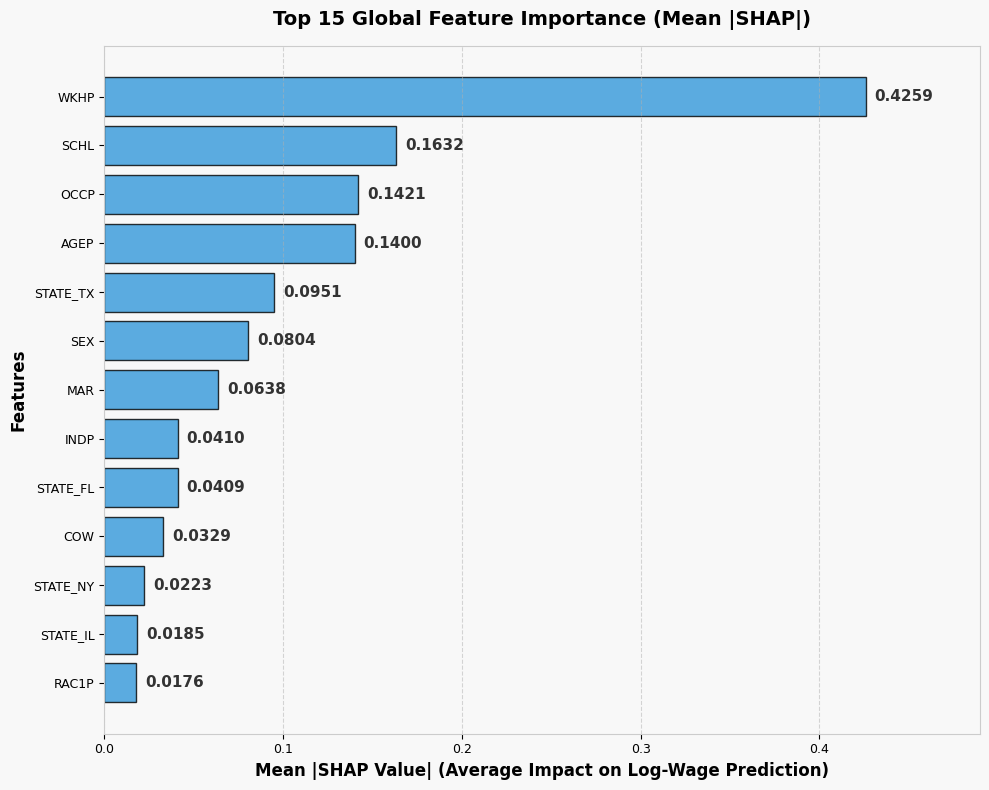

In [19]:
# =========================================================
# CUSTOM LABELED SHAP BAR PLOT (GLOBAL IMPORTANCE)
# =========================================================
print("\n===================================================")
print("GENERATING LABELED FEATURE IMPORTANCE CHART")
print("===================================================")

import matplotlib.pyplot as plt

# How many top features to show (adjust if you want more or less)
top_n = 15
plot_df = importance_df.head(top_n).copy()

# Sort ascending so the most important feature ends up at the very top of the graph
plot_df = plot_df.sort_values(by="Mean_SHAP_Impact", ascending=True)

plt.figure(figsize=(10, 8))

# Create the horizontal bars
bars = plt.barh(
    plot_df["Feature"],
    plot_df["Mean_SHAP_Impact"],
    color="#3498db",        # Nice clean blue
    edgecolor="black",
    alpha=0.8
)

# Loop through the bars and add the text labels
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.005,                       # X position: slightly to the right of the bar edge
        bar.get_y() + bar.get_height() / 2,  # Y position: center of the bar
        f"{width:.4f}",                      # The text: formatted to 4 decimal places
        va='center',                         # Vertical alignment
        ha='left',                           # Horizontal alignment
        fontsize=11,
        fontweight='bold',
        color='#333333'                      # Dark grey text
    )

# Formatting
plt.title(f"Top {top_n} Global Feature Importance (Mean |SHAP|)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Mean |SHAP Value| (Average Impact on Log-Wage Prediction)", fontweight='bold', fontsize=12)
plt.ylabel("Features", fontweight='bold', fontsize=12)

# Extend the x-axis slightly by 15% so the text labels don't get cut off at the edge
plt.xlim(0, plot_df["Mean_SHAP_Impact"].max() * 1.15)

# Add a light grid for readability
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Clean up layout and display
plt.tight_layout()
plt.show()


TOLERANCE VS ACCURACY GRAPH (ABSOLUTE DOLLARS)


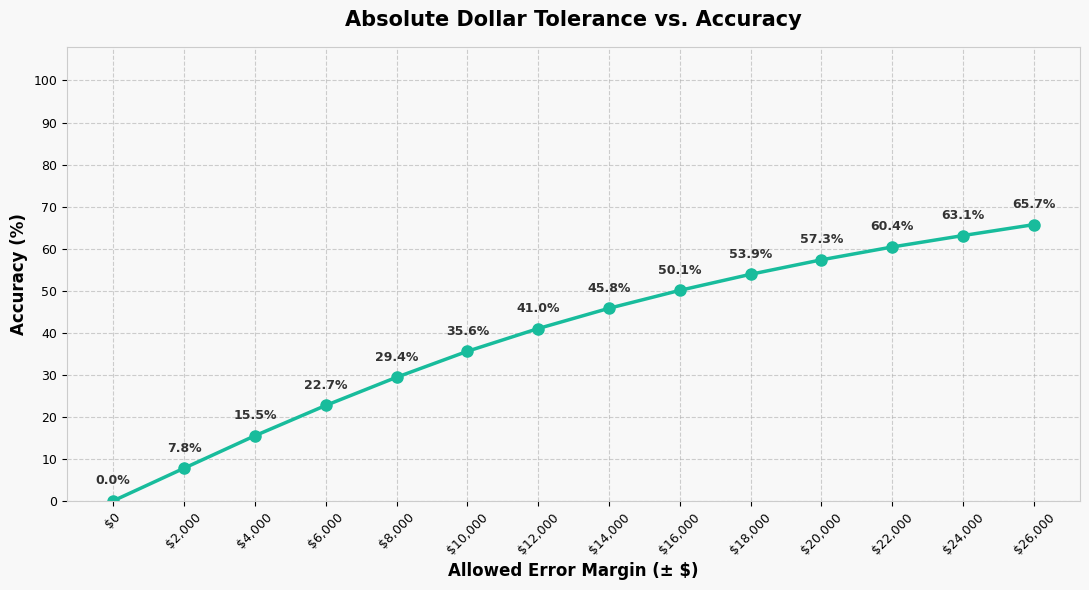


Absolute Dollar Tolerance vs Accuracy Breakdown:
--------------------------------------------------
Within ±$     0 tolerance ->   0.0% accuracy
Within ±$ 2,000 tolerance ->   7.8% accuracy
Within ±$ 4,000 tolerance ->  15.5% accuracy
Within ±$ 6,000 tolerance ->  22.7% accuracy
Within ±$ 8,000 tolerance ->  29.4% accuracy
Within ±$10,000 tolerance ->  35.6% accuracy
Within ±$12,000 tolerance ->  41.0% accuracy
Within ±$14,000 tolerance ->  45.8% accuracy
Within ±$16,000 tolerance ->  50.1% accuracy
Within ±$18,000 tolerance ->  53.9% accuracy
Within ±$20,000 tolerance ->  57.3% accuracy
Within ±$22,000 tolerance ->  60.4% accuracy
Within ±$24,000 tolerance ->  63.1% accuracy
Within ±$26,000 tolerance ->  65.7% accuracy


In [20]:
import matplotlib.pyplot as plt
import numpy as np

# =========================================================
# ABSOLUTE DOLLAR TOLERANCE VS ACCURACY GRAPH
# =========================================================
print("\n===================================================")
print("TOLERANCE VS ACCURACY GRAPH (ABSOLUTE DOLLARS)")
print("===================================================")

# Define absolute tolerances in dollars ($0 to $26,000 in steps of $2,000)
# You can change the 26000 (max) or 2000 (step) if you need a different range
tolerances_dollars = np.arange(0, 26001, 2000)
accuracies = []

# (Optional Check: Ensure these are in real dollars, not log scale)
# If they are still logged in your environment, uncomment the next two lines:
# y_test_dollars = np.expm1(y_test)
# predictions_dollars = np.expm1(predictions)

# Calculate the ABSOLUTE error in dollars for every single prediction
abs_error_dollars = np.abs(predictions_dollars - y_test_dollars)

# Calculate what percentage of predictions fall within each dollar tolerance level
for t in tolerances_dollars:
    acc = np.mean(abs_error_dollars <= t) * 100
    accuracies.append(acc)

# Plot the Graph
plt.figure(figsize=(11, 6))
plt.plot(tolerances_dollars, accuracies, marker='o', linestyle='-', color='#18BC9C', linewidth=2.5, markersize=8)

# Add the exact accuracy values above each dot
for i, txt in enumerate(accuracies):
    plt.annotate(
        f"{txt:.1f}%",
        (tolerances_dollars[i], accuracies[i]),
        textcoords="offset points",
        xytext=(0, 12),
        ha='center',
        fontsize=9,
        fontweight='bold',
        color='#333333'
    )

# Formatting the chart
plt.title("Absolute Dollar Tolerance vs. Accuracy", fontsize=15, fontweight='bold', pad=15)
plt.xlabel("Allowed Error Margin (± $)", fontweight='bold', fontsize=12)
plt.ylabel("Accuracy (%)", fontweight='bold', fontsize=12)

# Format the X-axis ticks to display as currency (e.g., $2,000)
formatter = plt.FuncFormatter(lambda x, loc: f"${int(x):,}")
plt.gca().xaxis.set_major_formatter(formatter)

plt.xticks(tolerances_dollars, rotation=45)
plt.yticks(np.arange(0, 101, 10))
plt.grid(True, linestyle='--', alpha=0.6)

# Set the upper Y-limit to 108 so the top labels don't get chopped off
plt.ylim(0, 108)

plt.tight_layout()
plt.show()

# Print the table output to the console as a backup
print("\nAbsolute Dollar Tolerance vs Accuracy Breakdown:")
print("-" * 50)
for t, a in zip(tolerances_dollars, accuracies):
    print(f"Within ±${t:>6,} tolerance -> {a:>5.1f}% accuracy")